In [ ]:
# Define the missing constants first
DATA_DIR = r"C:\Users\Mohan\Documents\driver_drowsiness\dataset"  # Parent directory containing 'drowsy' and 'alert' folders
IMG_HEIGHT = 128
IMG_WIDTH = 128
SEQUENCE_LENGTH = 20
NUM_CLASSES = 2

# Import necessary libraries
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dropout, Dense

def extract_frames(video_path, max_frames=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
        frame = frame / 25
        5.0
        frames.append(frame)
    cap.release()

    # Pad if less than SEQUENCE_LENGTH
    while len(frames) < max_frames:
        frames.append(np.zeros((IMG_HEIGHT, IMG_WIDTH, 3)))
    return np.array(frames)

# Load dataset
X = []
y = []

label_map = {'drowsy': 0, 'alert': 1}

# Print directory contents to debug
print(f"Checking contents of {DATA_DIR}:")
print(os.listdir(DATA_DIR))

for label in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, label)
    if not os.path.isdir(class_dir):
        continue  # Skip files, only process folders
    
    print(f"Processing {label} directory: {class_dir}")
    files = os.listdir(class_dir)
    print(f"Found {len(files)} files in {label} directory")
    
    for file in files:
        video_path = os.path.join(class_dir, file)
        if not video_path.lower().endswith((".mp4", ".avi")):  # Added .avi as another possible format
            print(f"Skipping non-video file: {file}")
            continue
        
        print(f"Processing video: {video_path}")
        frames = extract_frames(video_path)
        X.append(frames)
        y.append(label_map[label])

print(f"Processed {len(X)} videos in total")

# Only proceed if we have data
if len(X) > 0:
    X = np.array(X)
    y = to_categorical(np.array(y), num_classes=NUM_CLASSES)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model architecture
    model = Sequential([
        TimeDistributed(Conv2D(32, (3, 3), activation='relu'), input_shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Conv2D(64, (3, 3), activation='relu')),
        TimeDistributed(MaxPooling2D((2, 2))),
        TimeDistributed(Flatten()),
        LSTM(64),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()

    # Train
    model.fit(X_train, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))
else:
    print("No videos were processed. Please check your dataset directory structure and file formats.")

Checking contents of C:\Users\Mohan\Documents\driver_drowsiness\dataset:
['alert', 'drowsy']
Processing alert directory: C:\Users\Mohan\Documents\driver_drowsiness\dataset\alert
Found 1 files in alert directory
Processing video: C:\Users\Mohan\Documents\driver_drowsiness\dataset\alert\video.mp4
Processing drowsy directory: C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy
Found 4 files in drowsy directory
Processing video: C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy\WhatsApp Video 2025-07-13 at 15.54.44_e2503f6a.mp4
Processing video: C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy\WhatsApp Video 2025-07-13 at 15.54.50_300019ff.mp4
Processing video: C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy\WhatsApp Video 2025-07-13 at 15.55.02_f1690ab0.mp4
Processing video: C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy\WhatsApp Video 2025-07-13 at 15.55.43_2fea1ef1.mp4
Processed 5 videos in total


C:\Users\Mohan\anaconda3\envs\tfenv\lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 20, 126, 126, 32)    │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 20, 63, 63, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 20, 61, 61, 64)      │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 20, 30, 30, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 20, 57600)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │      14,762,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,785,922 (56.40 MB)

 Trainable params: 14,785,922 (56.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


In [2]:
model.save("cnn_lstm_drowsiness.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Model Performance Metrics:
   Metric  Score
 Accuracy    1.0
Precision    1.0
   Recall    1.0
 F1 Score    1.0


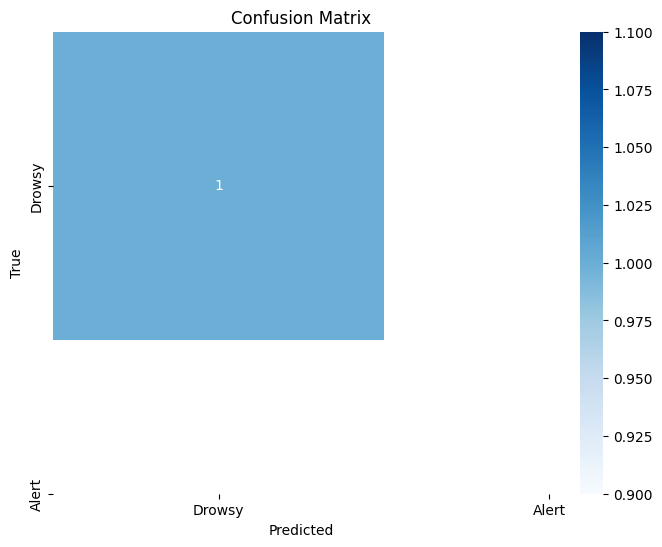

In [3]:
# Add these imports at the top
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
from tensorflow.keras.metrics import Precision, Recall

# Your existing code remains the same until after model training
# After model.fit(), add:

# Get predictions on test set
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Create a DataFrame to display metrics in a table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

# Display the metrics table
print("\nModel Performance Metrics:")
print(metrics_df.to_string(index=False))

# You can also create a confusion matrix for more detailed analysis
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Drowsy', 'Alert'],
            yticklabels=['Drowsy', 'Alert'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [4]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load model
model = load_model("cnn_lstm_drowsiness.h5")  # update with correct path

# Constants
IMG_WIDTH, IMG_HEIGHT = 64, 64
SEQUENCE_LENGTH = 30
LABELS = ["Eyes Closed", "Yawning", "Normal"]
COLORS = [(0, 0, 255), (0, 255, 255), (0, 255, 0)]  # Red, Yellow, Green


In [5]:
def preprocess_frames(frames):
    return np.array([cv2.resize(f, (IMG_WIDTH, IMG_HEIGHT)) / 255.0 for f in frames])


In [6]:

def run_prediction_on_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    label = "Detecting..."
    color = (255, 255, 0)  # Yellow for waiting

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        resized_frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
        norm_frame = resized_frame / 255.0
        frames.append(norm_frame)

        if len(frames) == SEQUENCE_LENGTH:
            input_seq = np.expand_dims(frames, axis=0)  # shape: (1, 30, 64, 64, 3)
            prediction = model.predict(input_seq, verbose=0)[0]
            class_id = np.argmax(prediction)
            label = LABELS[class_id]
            color = COLORS[class_id]
            frames.pop(0)  # slide window

        cv2.putText(frame, f"Status: {label}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
        cv2.imshow("Video Prediction", frame)
        if cv2.waitKey(25) & 0xFF == 27:
            break

    cap.release()
    cv2.destroyAllWindows()


In [7]:
run_prediction_on_video(r"C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy\WhatsApp Video 2025-07-13 at 15.55.02_f1690ab0.mp4")


In [8]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Constants (match training setup)
IMG_WIDTH = 128
IMG_HEIGHT = 128
SEQUENCE_LENGTH = 20

# Classes
LABELS = ["Eyes Closed", "Yawning", "Alert"]
COLORS = [(0, 0, 255), (0, 255, 255), (0, 255, 0)]  # Red, Yellow, Green

# Load trained model
model = load_model("cnn_lstm_drowsiness.h5")


In [1]:
def run_prediction_on_video(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    label = "Detecting..."
    color = (255, 255, 0)  # Yellow while waiting

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        resized_frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
        norm_frame = resized_frame / 255.0
        frames.append(norm_frame)

        if len(frames) == SEQUENCE_LENGTH:
            input_seq = np.expand_dims(frames, axis=0)  # (1, 20, 128, 128, 3)
            prediction = model.predict(input_seq, verbose=0)[0]
            class_id = np.argmax(prediction)
            label = LABELS[class_id]
            color = COLORS[class_id]
            frames.pop(0)  # sliding window

        # Overlay label on video
        cv2.putText(frame, f"Status: {label}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

        cv2.imshow("Drowsiness Detection", frame)
        if cv2.waitKey(25) & 0xFF == 27:  # ESC to exit
            break

    cap.release()
    cv2.destroyAllWindows()


In [2]:
run_prediction_on_video(r"C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy\WhatsApp Video 2025-07-13 at 15.55.43_2fea1ef1.mp4")


NameError: name 'cv2' is not defined

In [ ]:
video_folder = r"C:\Users\Mohan\Documents\driver_drowsiness\dataset\drowsy"

for file in os.listdir(video_folder):
    if file.lower().endswith(".mp4"):
        video_path = os.path.join(video_folder, file)
        print(f"Processing: {file}")
        run_prediction_on_video(video_path)
